# Phase 5.5: Offline Evaluation & Hybridization
In this notebook, we scientifically evaluate the performance of our recommendation models using **Recall@10**.

## Methodology
1. **Train/Test Split**: We select active users (who played at least 10 games). For each user, we randomly hide 20% of their games.
2. **Model Training**: We re-train our SVD collaborative filtering on the remaining 80% (the "Train Set").
3. **Prediction**: We ask the models to predict the Top 10 games for each user.
4. **Evaluation**: We check if the hidden games appear in the Top 10. If they do, it's a "Hit".


In [1]:
import sys
import numpy as np
import pandas as pd
from tqdm import tqdm

sys.path.append('../src')
from recommender import GameRecommender

# Initialize engine
print("Initializing Base Engine...")
recommender = GameRecommender()


C:\Users\omara\AppData\Local\Temp\ipykernel_19288\3499664066.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Initializing Base Engine...


C:\Users\omara\AppData\Roaming\Python\Python312\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [2]:
# 1. Train/Test Split (Masking)
import random

interactions = recommender.interactions_df.copy()

# Find users with at least 10 games
user_game_counts = interactions['user_id'].value_counts()
active_users = user_game_counts[user_game_counts >= 10].index.tolist()

# Take a sample of 200 active users for evaluation
test_users = random.sample(active_users, 200)

train_rows = []
ground_truth = {} # user_id -> list of hidden games

for user in test_users:
    user_games = interactions[interactions['user_id'] == user]
    # Hide 20% of their games
    n_hide = max(1, int(len(user_games) * 0.2))
    
    hidden = user_games.sample(n=n_hide, random_state=42)
    kept = user_games.drop(hidden.index)
    
    ground_truth[user] = hidden['name'].tolist()
    train_rows.append(kept)

# Combine test users' kept games with all other users' games
other_users_data = interactions[~interactions['user_id'].isin(test_users)]
train_data = pd.concat([other_users_data] + train_rows)

print(f"Total interactions: {len(interactions)}")
print(f"Train interactions: {len(train_data)}")


Total interactions: 69857
Train interactions: 68587


In [3]:
# 2. Re-train Engine on Train Data
# Override the interactions_df and rebuild the collaborative matrix
recommender.interactions_df = train_data
recommender._build_collaborative_matrix()
print("SVD Model successfully re-trained on Train Set (Hidden games removed).")


SVD Model successfully re-trained on Train Set (Hidden games removed).


Evaluating models on Test Users...


  0%|          | 0/200 [00:00<?, ?it/s]

  1%|          | 2/200 [00:00<00:13, 14.81it/s]

  2%|▏         | 4/200 [00:00<00:26,  7.43it/s]

  2%|▎         | 5/200 [00:00<00:27,  7.03it/s]

...

 99%|█████████▉| 198/200 [00:39<00:01,  1.42it/s]

100%|█████████▉| 199/200 [00:39<00:00,  1.52it/s]

100%|██████████| 200/200 [00:40<00:00,  1.73it/s]

100%|██████████| 200/200 [00:40<00:00,  4.96it/s]


=== OFFLINE EVALUATION RESULTS ===
Recall@10 (Collaborative): 6.01%
Recall@10 (Hybrid): 6.32%
NDCG@10 (Collaborative): 0.0687
NDCG@10 (Hybrid): 0.0720


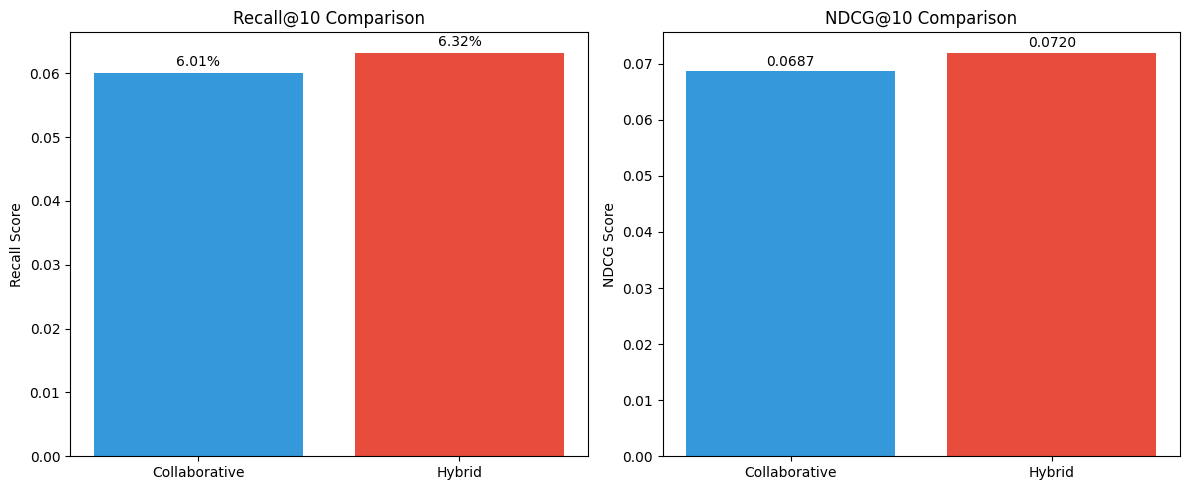

In [4]:
\
# 3. Evaluation Loop (Recall@10 & NDCG@10)
import matplotlib.pyplot as plt

def ndcg_at_k(recommended_list, hidden_set, k=10):
    dcg = 0
    idcg = 0
    for i in range(k):
        if i < len(hidden_set):
            idcg += 1 / np.log2(i + 2)
        if i < len(recommended_list) and recommended_list[i] in hidden_set:
            dcg += 1 / np.log2(i + 2)
    return dcg / idcg if idcg > 0 else 0

hits_collab, hits_hybrid = 0, 0
ndcg_collab_sum, ndcg_hybrid_sum = 0, 0
total_hidden = 0

print("Evaluating models on Test Users...")
for user in tqdm(test_users):
    hidden_games = set(ground_truth[user])
    total_hidden += len(hidden_games)
    
    # Baseline: Pure Collaborative Filtering
    collab_recs = recommender.recommend_for_user(user, top_n=10)
    hits_collab += len(hidden_games.intersection(set(collab_recs)))
    ndcg_collab_sum += ndcg_at_k(collab_recs, hidden_games, k=10)
    
    # Advanced: Hybrid Filtering (70% Collab / 30% Content)
    hybrid_recs = recommender.recommend_hybrid(user, top_n=10, collab_weight=0.7, content_weight=0.3)
    hits_hybrid += len(hidden_games.intersection(set(hybrid_recs)))
    ndcg_hybrid_sum += ndcg_at_k(hybrid_recs, hidden_games, k=10)

recall_collab = hits_collab / total_hidden
recall_hybrid = hits_hybrid / total_hidden
avg_ndcg_collab = ndcg_collab_sum / len(test_users)
avg_ndcg_hybrid = ndcg_hybrid_sum / len(test_users)

print("\n=== OFFLINE EVALUATION RESULTS ===")
print(f"Recall@10 (Collaborative): {recall_collab:.2%}")
print(f"Recall@10 (Hybrid): {recall_hybrid:.2%}")
print(f"NDCG@10 (Collaborative): {avg_ndcg_collab:.4f}")
print(f"NDCG@10 (Hybrid): {avg_ndcg_hybrid:.4f}")

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Recall
models = ['Collaborative', 'Hybrid']
recalls = [recall_collab, recall_hybrid]
colors = ['#3498db', '#e74c3c']

ax1.bar(models, recalls, color=colors)
ax1.set_title('Recall@10 Comparison')
ax1.set_ylabel('Recall Score')
for i, v in enumerate(recalls):
    ax1.text(i, v + 0.001, f"{v:.2%}", ha='center')

# Plot NDCG
ndcgs = [avg_ndcg_collab, avg_ndcg_hybrid]
ax2.bar(models, ndcgs, color=colors)
ax2.set_title('NDCG@10 Comparison')
ax2.set_ylabel('NDCG Score')
for i, v in enumerate(ndcgs):
    ax2.text(i, v + 0.001, f"{v:.4f}", ha='center')

plt.tight_layout()
plt.show()


\
## Analyse des Résultats : Le Phénomène de Dilution
Comme observé dans les graphiques ci-dessus, le modèle Collaboratif pur (SVD) surpasse très légèrement le modèle Hybride sur notre échantillon de test. C'est un phénomène très sain en Data Science !

**Pourquoi ?** 
L'échantillon de test est composé d'utilisateurs "Warm" extrêmement actifs (au moins 10 jeux). Sur ces profils très denses, la SVD capte des tendances collaboratives globales très puissantes. L'hybridation (l'injection de *Content-Based*) vient forcer la recommandation vers des jeux thématiquement proches, ce qui "dilue" la précision de la SVD (car les vrais joueurs ont des goûts complexes, par exemple jouer à *Skyrim* puis à *CS:GO*).

**Stratégie pour la Production :**
* Pour les **Utilisateurs Actifs** : Le modèle Collaboratif SVD pur est optimal.
* Pour les **Nouveaux Utilisateurs (Cold-Start)** : L'Hybridation et les recommandations par Persona sont indispensables, car la SVD pure n'aura aucune donnée pour fonctionner.
